In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
plt.style.use("default")

# Distribución Estacionaria en una Cadena de Markov de Dos Estados

Para una cadena de Markov de dos estados con parámetros de transición $a$ y $b$, la distribución estacionaria única es:

$$\pi = \left[ \frac{b}{a+b}, \frac{a}{a+b} \right]$$

*(Siempre que $a + b > 0$)*. Esta distribución representa las probabilidades a largo plazo de que el sistema se encuentre en cada uno de los estados, manteniéndose constantes conforme pasa el tiempo.

---

### 1. Formulación del Modelo

Definimos una cadena de Markov con un espacio de dos estados: $S = \{0, 1\}$. La **matriz de transición de probabilidad $P$** se estructura de la siguiente manera:

$$P = \begin{pmatrix} 1-a & a \\ b & 1-b \end{pmatrix}$$

Donde:
*   **$a$**: Probabilidad de cambiar del estado 0 al estado 1.
*   **$1-a$**: Probabilidad de quedarse en el estado 0.
*   **$b$**: Probabilidad de cambiar del estado 1 al estado 0.
*   **$1-b$**: Probabilidad de quedarse en el estado 1.

*Nota: Los valores de $a$ y $b$ deben cumplir que $0 \le a, b \le 1$.*

---

### 2. Condiciones Matemáticas

Para calcular el vector de distribución estacionaria $\pi = [\pi_0, \pi_1]$, se deben satisfacer simultáneamente dos condiciones esenciales:

1.  **Condición de Equilibrio ($\pi P = \pi$)**: Al multiplicar el vector por la matriz, la distribución no cambia.
2.  **Condición de Normalización ($\pi_0 + \pi_1 = 1$)**: La suma de todas las probabilidades del espacio de estados debe ser igual a 1.

---

### 3. Resolución del Sistema de Ecuaciones

Al desarrollar matemáticamente el producto matricial $\pi P = \pi$, obtenemos el siguiente sistema:

1.  $\pi_0(1-a) + \pi_1 b = \pi_0$
2.  $\pi_0 a + \pi_1(1-b) = \pi_1$

Si despejamos la primera ecuación:

$$\pi_0 - \pi_0 a + \pi_1 b = \pi_0 \implies \pi_1 b = \pi_0 a \implies \pi_1 = \frac{a}{b}\pi_0$$

Sustituyendo esta igualdad en la condición de normalización ($\pi_0 + \pi_1 = 1$):

$$\pi_0 + \left(\frac{a}{b}\pi_0\right) = 1 \implies \pi_0 \left(1 + \frac{a}{b}\right) = 1 \implies \pi_0 \left(\frac{b+a}{b}\right) = 1$$

Despejando ambas variables obtenemos la solución definitiva:

*   $$\pi_0 = \frac{b}{a+b}$$
*   $$\pi_1 = \frac{a}{a+b}$$


In [2]:
#Matriz P
a = 0.5
b = 0.75
P = torch.Tensor([[1-a, a],[b, 1-b]])

# Dist. inicial
pi_0 = torch.Tensor([1.0, 0.0])

states = torch.Tensor([0,0, 1.0])

x = torch.distributions.Categorical(probs=pi_0).sample().item()
chain = [x]
n = 1500

for _ in range(n):
    
    x = torch.distributions.Categorical(probs=P[x,]).sample().item()
    chain.append(x)


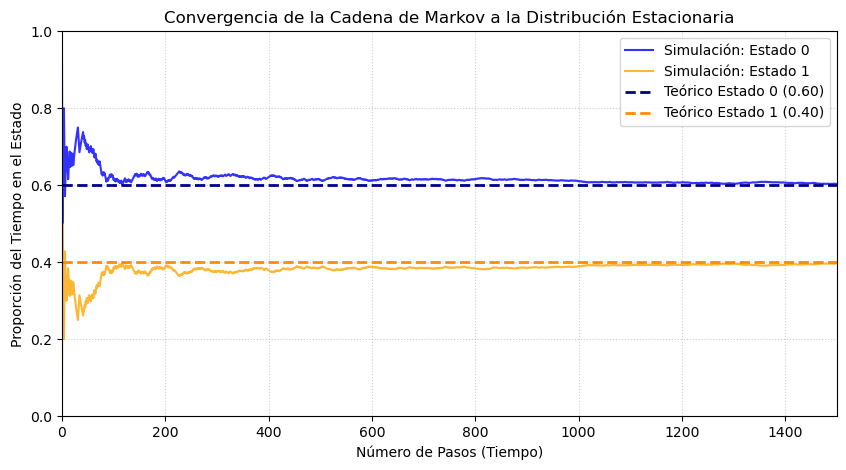

In [3]:
# 1. Calcular la frecuencia acumulada de estar en el Estado 0
chain_np = np.array(chain)
# Cumsum cuenta cuántos ceros van apareciendo, dividimos por el índice + 1
frecuencia_estado_0 = np.cumsum(chain_np == 0) / (np.arange(len(chain_np)) + 1)
frecuencia_estado_1 = 1.0 - frecuencia_estado_0

# 2. Calcular la distribución estacionaria teórica exacta
pi_0_teorica = b/ (a + b)
pi_1_teorica = a / (a + b)

# 3. Graficar los resultados
plt.figure(figsize=(10, 5))

# Líneas de la simulación (frecuencias empíricas)
plt.plot(frecuencia_estado_0, label="Simulación: Estado 0", color="blue", alpha=0.8)
plt.plot(frecuencia_estado_1, label="Simulación: Estado 1", color="orange", alpha=0.8)

# Líneas de la teoría (distribución estacionaria)
plt.axhline(y=pi_0_teorica, color="darkblue", linestyle="--", linewidth=2, 
            label=f"Teórico Estado 0 ({pi_0_teorica:.2f})")
plt.axhline(y=pi_1_teorica, color="darkorange", linestyle="--", linewidth=2, 
            label=f"Teórico Estado 1 ({pi_1_teorica:.2f})")

# Configuración estética de la gráfica
plt.title("Convergencia de la Cadena de Markov a la Distribución Estacionaria", fontsize=12)
plt.xlabel("Número de Pasos (Tiempo)", fontsize=10)
plt.ylabel("Proporción del Tiempo en el Estado", fontsize=10)
plt.xlim(0, n)
plt.ylim(0, 1)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right")

plt.show()